In [1]:
import astropy.units as u
import astropy.constants as const
import numpy as np

%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from tqdm.notebook import tqdm
import json
import h5py
import os

import warnings
warnings.filterwarnings("ignore")


from DiscEvolution.grid import Grid
from DiscEvolution.star import SimpleStar
from DiscEvolution.eos import LocallyIsothermalEOS  
from DiscEvolution.eos import SimpleDiscEOS
from DiscEvolution.eos import IrradiatedEOS  
from DiscEvolution.disc import AccretionDisc
from DiscEvolution.viscous_evolution import ViscousEvolutionFV
from DiscEvolution.driver import PlanetDiscDriver
from DiscEvolution.io import Event_Controller
from DiscEvolution.dust import DustGrowthTwoPop, SingleFluidDrift
from DiscEvolution.viscous_evolution import HybridWindModel
from DiscEvolution.opacity import Zhu2012
from DiscEvolution.constants import yr as yr_code, GasConst, Omega0, AU, Msun  # DiscEvolution uses code units: 1 year = 2π code time units
from DiscEvolution.chemistry import SimpleCOAtomAbund, EquilibriumCOChemOberg
from DiscEvolution import planet_formation as pf
from DiscEvolution.diffusion import TracerDiffusion 
from DiscEvolution.planet_formation import Planets, Bitsch2015Model
from DiscEvolution.constants import *

In [2]:
def h5_to_dict(h5obj):
    out = {}
    for k, v in h5obj.items():
        if isinstance(v, h5py.Dataset):
            out[k] = v[()]          # load dataset into memory
        else:
            out[k] = h5_to_dict(v)  # recurse into group
    return out     

# crPath = "/Users/james/Documents/GitHub/DiscEvolution/james/august2026/output/CR_0.1Myr/winds_mig_psi10.0_Mdot1.0e-08_M1.0e-01_Rd5.0e+01_20260826_135307.h5"
crPath = "/Users/james/Documents/GitHub/DiscEvolution/james/august2026/output/CR_0.01Myr/trig/winds_mig_psi10.0_Mdot1.0e-08_M1.0e-01_Rd5.0e+01_20260901_170258.h5"

print('\n  -------- data ---------')
with h5py.File(crPath, "r") as f:
    CRdata = h5_to_dict(f)
    CRattrs = dict(f.attrs)

for i in CRdata.keys():
    print(i)


xrPath = "/Users/james/Documents/GitHub/DiscEvolution/james/august2026/output/XR_0.1Myr/winds_mig_psi10.0_Mdot1.0e-08_M1.0e-01_Rd5.0e+01_20260826_135335.h5"
# xrPath = "/Users/james/Documents/GitHub/DiscEvolution/james/august2026/output/XR_0.1Myr/winds_mig_psi10.0_Mdot1.0e-08_M1.0e-01_Rd5.0e+01_20260826_163825.h5"


with h5py.File(xrPath, "r") as f:
    XRdata = h5_to_dict(f)
    XRattrs = dict(f.attrs)


  -------- data ---------
B_xe
C_xe
D_xe
H
JXR
Lambda
M_iso
M_transition
Mcs
Mes
NH
P
R
R_dz
R_dz_t
Rp
Sigc
Sigma_G
Sigma_dust
Sigma_grain_size
Sigma_pebble_size
Sigma_pebbles
Sigma_planetesimals
St
T
Tc
Vdrift
X_cores
X_envs
alpha_R
disk_Mass
disk_Mdot_p
disk_Mdot_star
disk_atom_gas_abund
disk_atom_ice_abund
disk_ice_lines
disk_mol_gas_abund
disk_mol_ice_abund
disk_planetesimal_atom_abund
disk_planetesimal_mol_abund
eta_diff
ice_lines
n_density
nu
psi_R
rho_mid
sigmaXR
t
tau_XR
time_snap
xe
zeta
zeta_CR
zeta_XR


In [3]:
crR = CRdata["R"]
crtsnap = CRdata["time_snap"]    # Myr        
crSigma_g = CRdata["Sigma_G"]   

crRdz = CRdata['R_dz_t']
crt = CRdata["t"]                # yr

crZeta = CRdata['zeta']
crZetaCR = CRdata['zeta_CR']
crZetaXR = CRdata['zeta_XR']

crLambda = CRdata['Lambda']
crT = CRdata['T']
crxe = CRdata['xe']

In [4]:
xrR = XRdata["R"]
xrtsnap = XRdata["time_snap"]    # Myr        
xrSigma_g = XRdata["Sigma_G"]   

xrRdz = XRdata['R_dz_t']
xrt = XRdata["t"]                # yr

xrZeta = XRdata['zeta']
xrZetaCR = XRdata['zeta_CR']
xrZetaXR = XRdata['zeta_XR']

xrLambda = XRdata['Lambda']
xrT = XRdata['T']
xrNH = XRdata['NH']

In [5]:
arr1 = crtsnap*1e6
arr2 = crt

# Find the insertion positions
idx = np.searchsorted(arr2, arr1)

# Handle edge cases where the index falls outside array boundaries
idx = np.clip(idx, 1, len(arr2) - 1)

# Check whether the left or right neighbor is closer
left_closer = np.abs(arr1 - arr2[idx - 1]) < np.abs(arr1 - arr2[idx])
closest_indices = np.where(left_closer, idx - 1, idx)

print(closest_indices)

[  0  35 181 342]


In [6]:
crt[closest_indices]/1e6

array([3.78369361e-05, 1.01067674e-03, 5.00601034e-03, 1.00000000e-02])

Text(0.5, 1.0, 'CR')

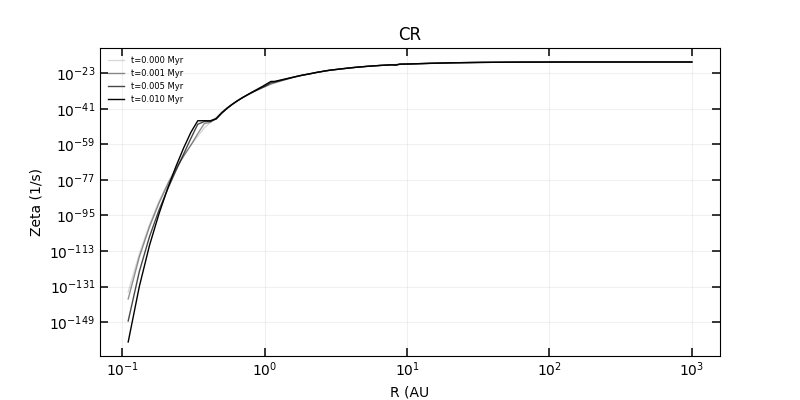

In [7]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)


#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))

xdata = crR
ydata = crZeta

for a_i, i in enumerate(idx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='black', alpha=alphas[a_i],
                label=rf"t={crt[i]/1e6:.3f} Myr", lw = 1.0)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU')
ax.set_ylabel('Zeta (1/s)')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('CR')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

Text(0.5, 1.0, 'CR')

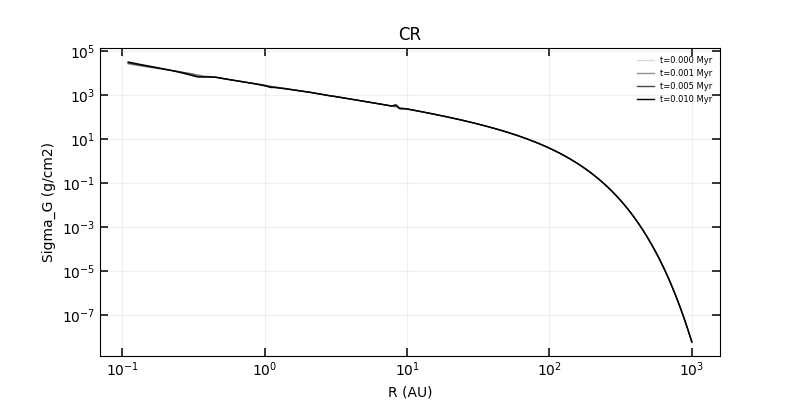

In [8]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)

#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(crtsnap))

xdata = crR
ydata = crSigma_g

for a_i, i in enumerate(range(0,4)):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='black', alpha=alphas[a_i],
                label=rf"t={crtsnap[i]:.3f} Myr", lw = 1.0)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('Sigma_G (g/cm2)')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('CR')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

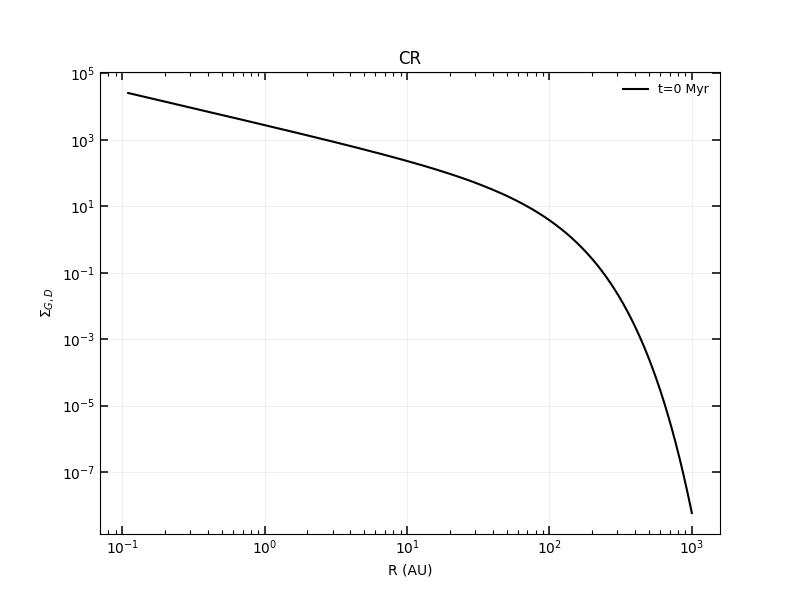

In [9]:
fig, ax = plt.subplots(figsize=(8, 6), sharex=True, dpi=100, sharey=True)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

plt.loglog(crR, crSigma_g[0], color='black', ls = 'solid', label=f"t={crtsnap[0]:.3g} Myr")
ax.set_ylabel(r'$\Sigma_{G,D}$')
ax.set_xlabel('R (AU)')
plt.title('CR')

ax.legend(frameon=False, fontsize=9, loc="best")

Text(0.5, 1.0, 'CR and XR ')

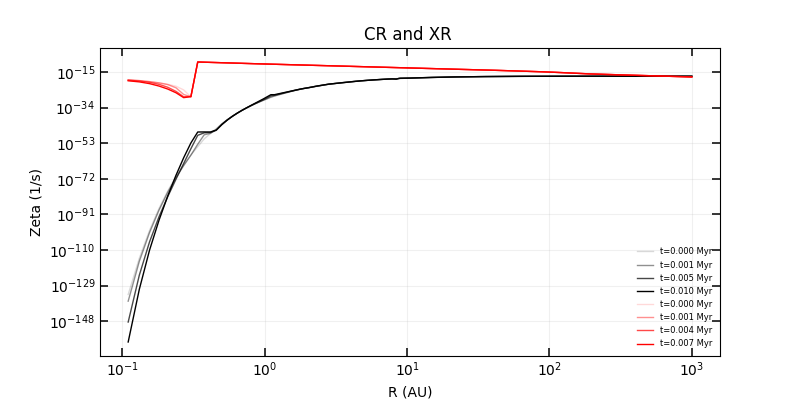

In [10]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)


#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))

xdata = crR
ydata = crZeta

for a_i, i in enumerate(idx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='black', alpha=alphas[a_i],
                label=rf"t={crt[i]/1e6:.3f} Myr", lw = 1.0)

xdata = xrR
ydata = xrZeta

for a_i, i in enumerate(idx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={xrt[i]/1e6:.3f} Myr", lw = 1.0)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('CR and XR ')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

Text(0.5, 1.0, 'XR')

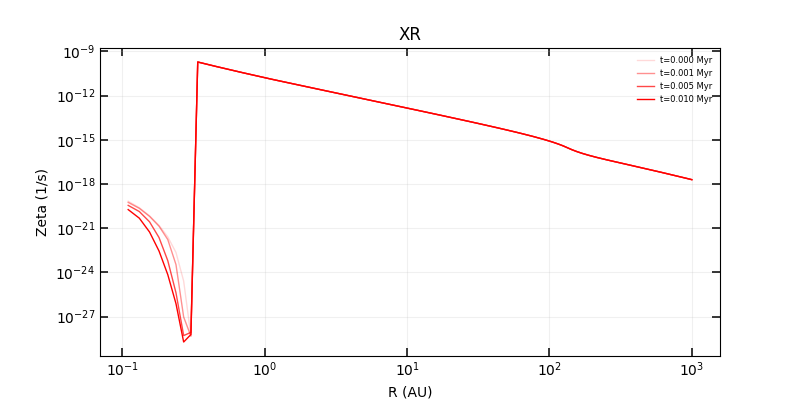

In [11]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)


#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))

xdata = xrR
ydata = xrZeta

for a_i, i in enumerate(idx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={crt[i]/1e6:.3f} Myr", lw = 1.0)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('XR')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

Text(0.5, 1.0, 'XR')

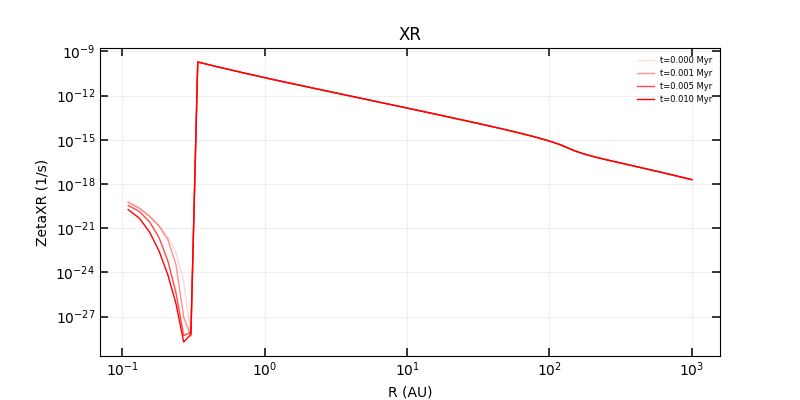

In [12]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)


#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))

xdata = xrR
ydata = xrZetaXR

for a_i, i in enumerate(idx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={crt[i]/1e6:.3f} Myr", lw = 1.0)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('ZetaXR (1/s)')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('XR')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

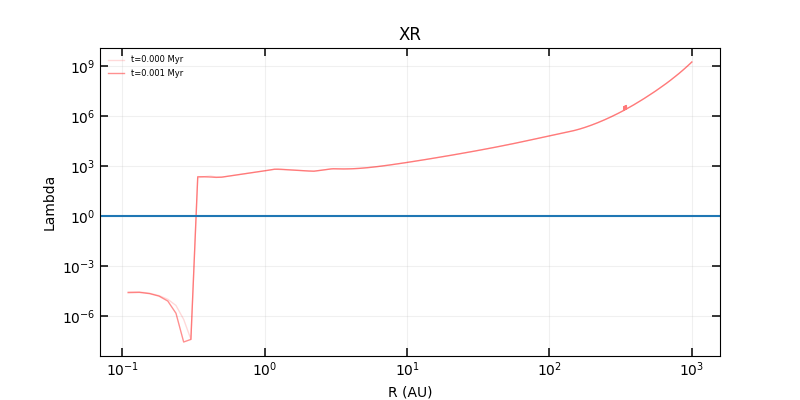

In [13]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)


#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))

xdata = xrR
ydata = xrLambda

for a_i, i in enumerate(idx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={xrt[i]/1e6:.3f} Myr", lw = 1.0)
    if i > 3: 
        break

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('Lambda')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('XR')

ax.axhline(1)

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

Text(0.5, 1.0, 'XR')

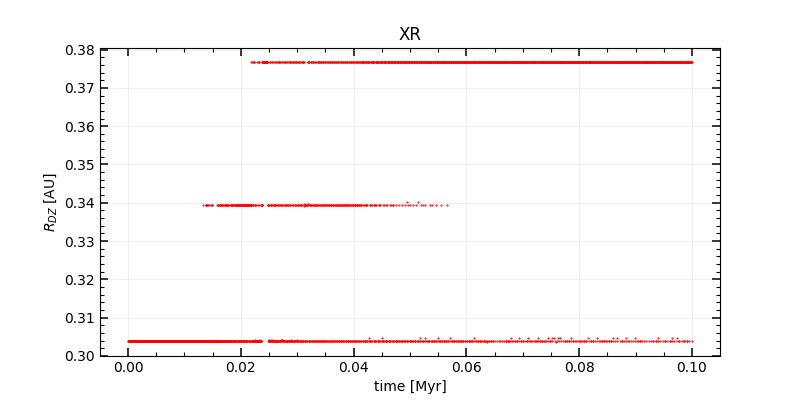

In [14]:
fig, ax = plt.subplots(figsize=(8, 4), sharex=True, dpi=100, sharey=True)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

plt.plot(xrt/1e6, xrRdz, '.r', ms = 1.0)
ax.set_ylabel(r'$R_{DZ}$ [AU]')
ax.set_xlabel('time [Myr]')
plt.title('XR')

# ax.legend(frameon=False, fontsize=9, loc="best")

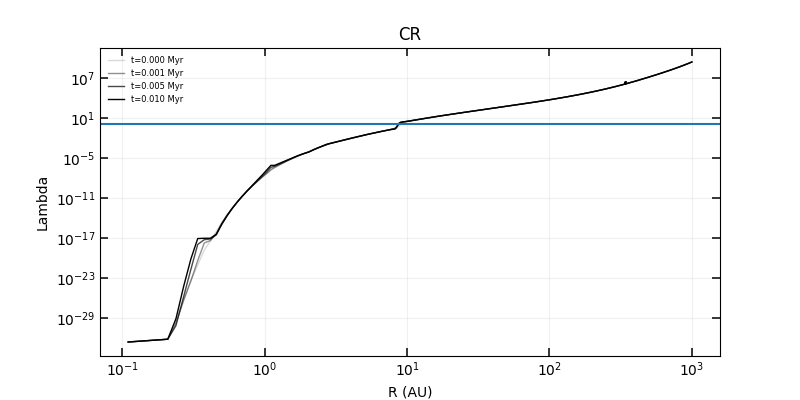

In [15]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)


#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))

xdata = crR
ydata = crLambda

for a_i, i in enumerate(idx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='black', alpha=alphas[a_i],
                label=rf"t={crt[i]/1e6:.3f} Myr", lw = 1.0)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('Lambda')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('CR')

ax.axhline(1)

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

Text(0.5, 1.0, 'CR')

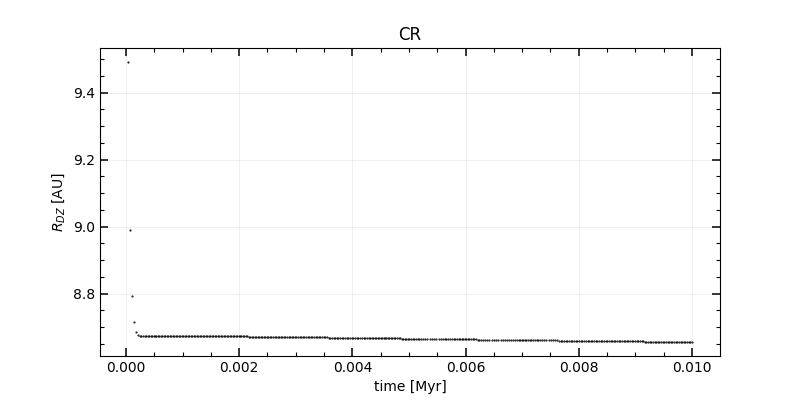

In [16]:
fig, ax = plt.subplots(figsize=(8, 4), sharex=True, dpi=100, sharey=True)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

plt.plot(crt/1e6, crRdz, '.k', ms = 1.0)
ax.set_ylabel(r'$R_{DZ}$ [AU]')
ax.set_xlabel('time [Myr]')
plt.title('CR')

# ax.legend(frameon=False, fontsize=9, loc="best")

Text(0.5, 1.0, 'CR')

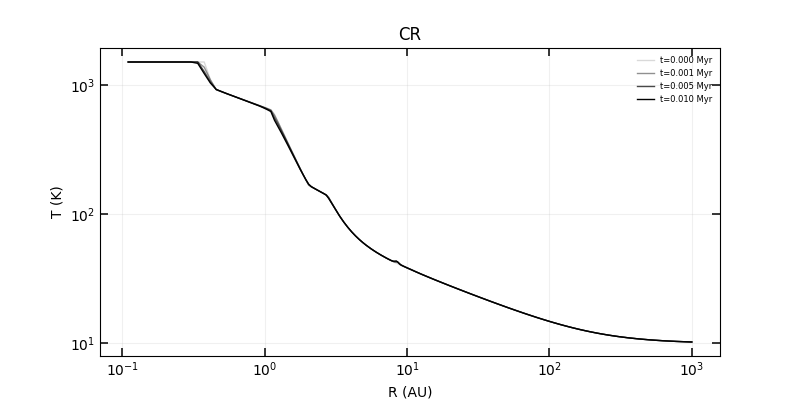

In [17]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)

#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(crtsnap))

xdata = crR
ydata = crT

for a_i, i in enumerate(range(0,4)):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='black', alpha=alphas[a_i],
                label=rf"t={crtsnap[i]:.3f} Myr", lw = 1.0)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('T (K)')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('CR')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

Text(0.5, 1.0, 'XR')

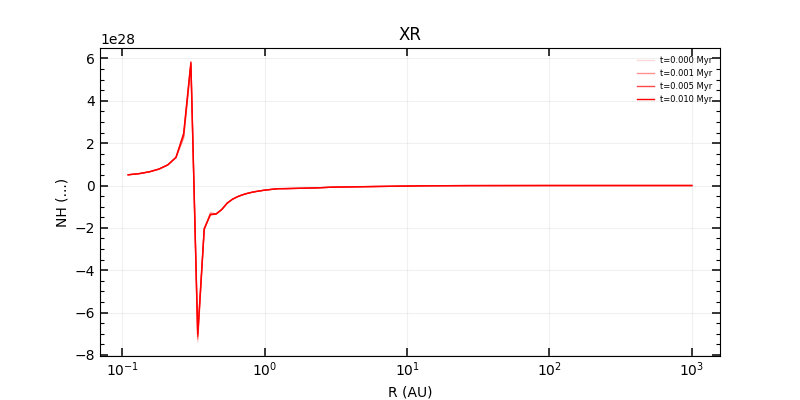

In [18]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)

#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(crtsnap))

xdata = xrR
ydata = xrNH

for a_i, i in enumerate(range(0,4)):
    ax.semilogx(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={xrtsnap[i]:.3f} Myr", lw = 1.0)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('NH (...)')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('XR')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

Text(0.5, 1.0, 'XR')

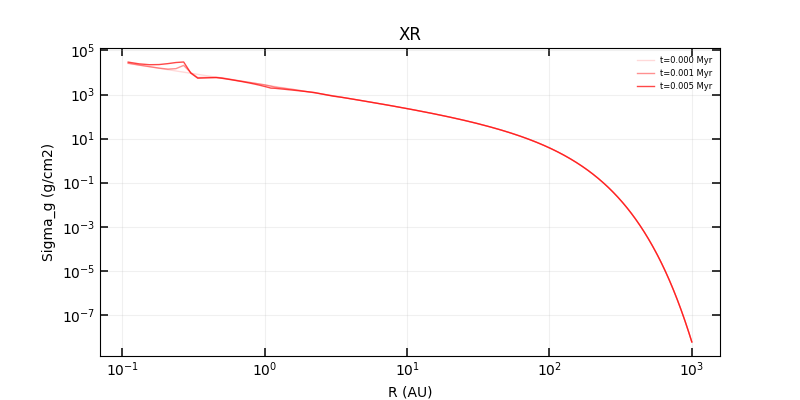

In [19]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)

#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(crtsnap))

xdata = xrR
ydata = xrSigma_g

for a_i, i in enumerate(range(0,4)):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={xrtsnap[i]:.3f} Myr", lw = 1.0)
    if i > 1: 
        break

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('Sigma_g (g/cm2)')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('XR')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

# XR with trig instead

In [20]:
# original trig
# trPath = "/Users/james/Documents/GitHub/DiscEvolution/james/august2026/output/XR_0.1Myr/winds_mig_psi10.0_Mdot1.0e-08_M1.0e-01_Rd5.0e+01_20260826_163825.h5"
# trig with arctan(|dz|/|dr|)
trPath = "/Users/james/Documents/GitHub/DiscEvolution/james/august2026/output/XR_0.01Myr/winds_mig_psi10.0_Mdot1.0e-08_M1.0e-01_Rd5.0e+01_20260827_152206.h5"
# trig with 2003 |sin(alphaprime)|
# trPath = "/Users/james/Documents/GitHub/DiscEvolution/james/august2026/output/XR_0.01Myr/2003/winds_mig_psi10.0_Mdot1.0e-08_M1.0e-01_Rd5.0e+01_20260827_153500.h5"

with h5py.File(trPath, "r") as f:
    TRdata = h5_to_dict(f)
    TRattrs = dict(f.attrs)

In [21]:
trR = TRdata["R"]
trtsnap = TRdata["time_snap"]    # Myr        
trSigma_g = TRdata["Sigma_G"]   

trRdz = TRdata['R_dz_t']
trt = TRdata["t"]                # yr

trZeta = TRdata['zeta']
trZetaCR = TRdata['zeta_CR']
trZetaXR = TRdata['zeta_XR']

trLambda = TRdata['Lambda']
trT = TRdata['T']
trNH = TRdata['NH']
trJ = TRdata['JXR']
trsigma = TRdata['sigmaXR']
trtau = TRdata['tau_XR']

trH = TRdata['H']

In [22]:
arr1 = trtsnap*1e6
arr2 = trt

# Find the insertion positions
idx = np.searchsorted(arr2, arr1)

# Handle edge cases where the index falls outside array boundaries
idx = np.clip(idx, 1, len(arr2) - 1)

# Check whether the left or right neighbor is closer
left_closer = np.abs(arr1 - arr2[idx - 1]) < np.abs(arr1 - arr2[idx])
closest_indices = np.where(left_closer, idx - 1, idx)

print(closest_indices)

[  0  35 181 342]


Text(0.5, 1.0, 'XR trig')

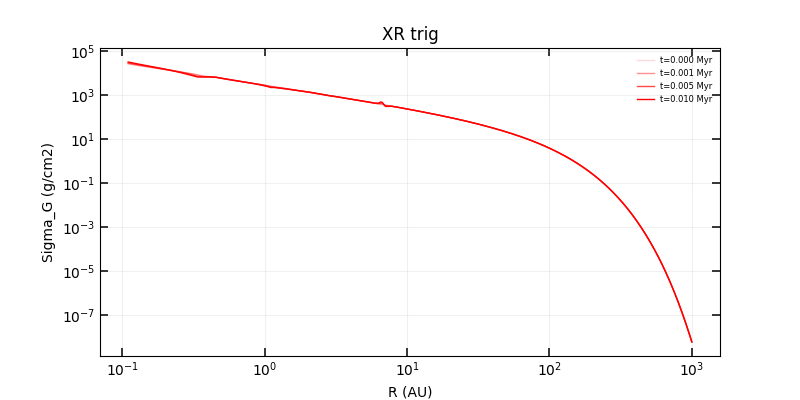

In [23]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)

#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(crtsnap))

xdata = trR
ydata = trSigma_g

for a_i, i in enumerate(range(0,4)):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={crtsnap[i]:.3f} Myr", lw = 1.0)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('Sigma_G (g/cm2)')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('XR trig')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

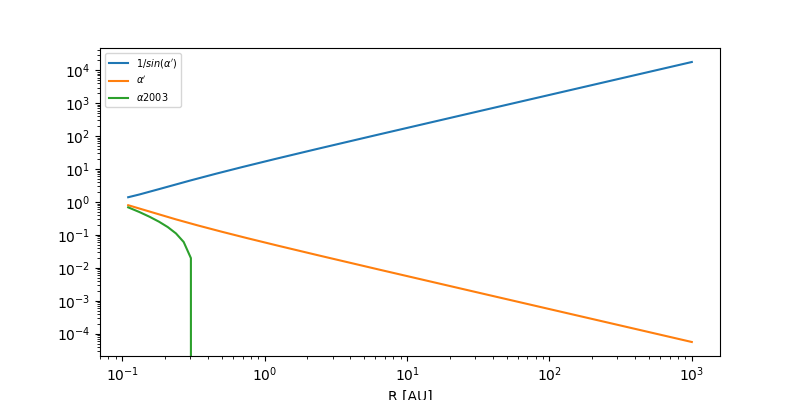

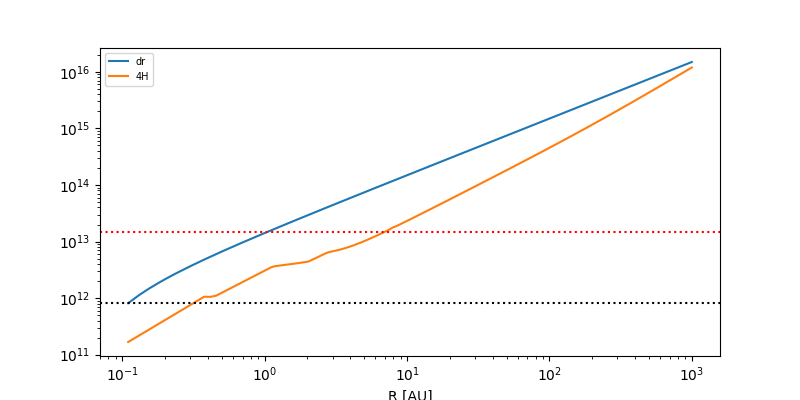

In [24]:
source_R = 12.0 * Rsun
source_z = 12.0 * Rsun
R_cm = trR * AU             # Not a fx of t , R only saved once (1000,)
fourH = 4 * trH * AU

dr = R_cm - source_R
dz = source_z
alpha_prime = np.arctan2(dz, dr) # y, x
geometry_factor = 1.0 / np.sin(alpha_prime)

Nperp = trSigma_g / (2.0 * 2.4 * m_H)



Rstar = 1.0 * Rsun                       # cm
H = 4.0 * trH[0] * AU                             # cm

# disk radius
a = trR * AU                                   # cm

dlnH_dlna = np.gradient(np.log(H), np.log(a))      # unitless

# Chiang 2001
alpha = np.arctan( dlnH_dlna * (H / a) ) - np.arctan( H / a ) + np.arcsin( (4 * Rstar)/( 3*np.pi*a) ) 

# Matsumura & Pudritz 2003
beta = np.arctan( dlnH_dlna * (H / a) )

# Matsumura & Pudritz 2003
gamma = np.arctan( (H - 0.5*Rstar)/(a - 0.5*np.sqrt(3)*Rstar) ) - np.arctan( (H - source_R)/(a - source_z) )

alpha_2003 = alpha - beta + gamma


fig, ax = plt.subplots(figsize=(8, 4))
# ax.loglog(trR, Nperp[0], label=r"$N_\perp$")
ax.loglog(trR, geometry_factor, label=r"$1/sin(\alpha')$")
# ax.loglog(trR, trNH[0], label=r"$N_H$")
# ax.loglog(trR, Nperp[0] * geometry_factor, label=r"$N_\perp * 1/sin(\alpha')$")
ax.loglog(trR, alpha_prime, label=r"$\alpha'$")
ax.loglog(trR, alpha_2003, label=r"$\alpha 2003$")
# ax.loglog(trR, fourH[0], label=r"4H")
# ax.axhline(y = source_z, ls = 'dotted', color = 'black')
ax.set_xlabel("R [AU]")
ax.set_ylabel("")
ax.legend(loc='best',fontsize=7)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(trR, dr, label=r"dr")
# ax.loglog(trR, dz, label=r"dz")
ax.loglog(trR, fourH[0], label=r"4H")
ax.axhline(y = source_z, ls = 'dotted', color = 'black')
ax.axhline(y = AU, ls = 'dotted', color = 'red')
ax.set_xlabel("R [AU]")
ax.set_ylabel("")
ax.legend(loc='best',fontsize=7)
plt.show()

Text(0.5, 1.0, 'XR trig')

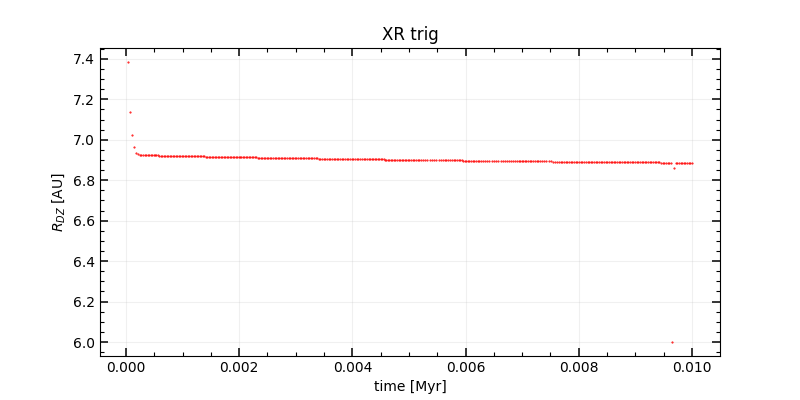

In [25]:
fig, ax = plt.subplots(figsize=(8, 4), sharex=True, dpi=100, sharey=True)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

plt.plot(trt/1e6, trRdz, '.r', ms = 1.0)
ax.set_ylabel(r'$R_{DZ}$ [AU]')
ax.set_xlabel('time [Myr]')
plt.title('XR trig')

# ax.legend(frameon=False, fontsize=9, loc="best")

Text(0.5, 1.0, 'XR trig')

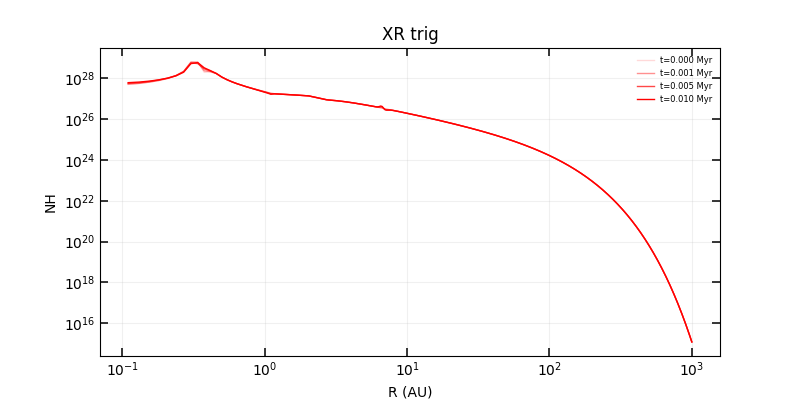

In [26]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)


#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))

xdata = trR
ydata = trNH

for a_i, i in enumerate(idx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={crt[i]/1e6:.3f} Myr", lw = 1.0)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('NH')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('XR trig')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

Text(0.5, 1.0, 'XR trig')

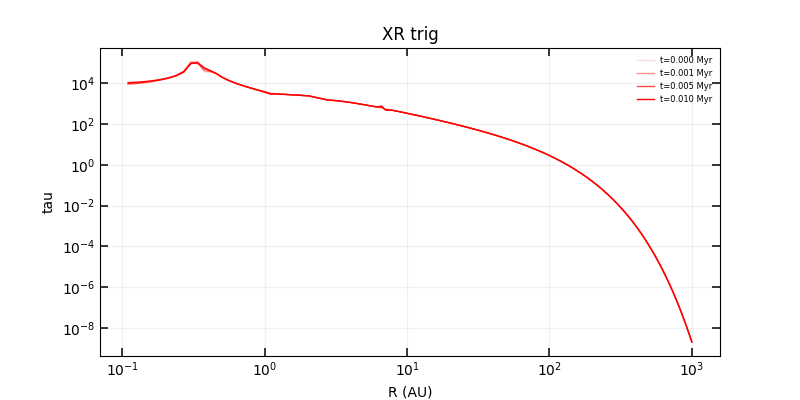

In [27]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)


#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))

xdata = trR
ydata = trtau

for a_i, i in enumerate(idx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={crt[i]/1e6:.3f} Myr", lw = 1.0)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('tau')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('XR trig')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

Text(0.5, 1.0, 'XR trig')

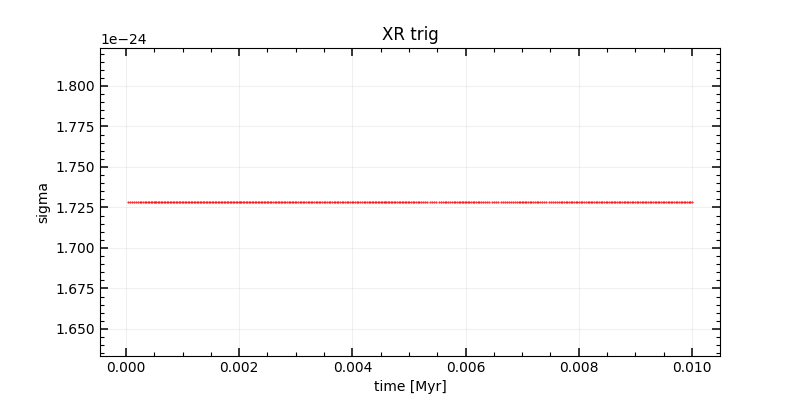

In [28]:
fig, ax = plt.subplots(figsize=(8, 4), sharex=True, dpi=100, sharey=True)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

plt.plot(trt/1e6, trsigma, '.r', ms = 1.0)
ax.set_ylabel('sigma')
ax.set_xlabel('time [Myr]')
plt.title('XR trig')

# ax.legend(frameon=False, fontsize=9, loc="best")

Text(0.5, 1.0, 'XR trig')

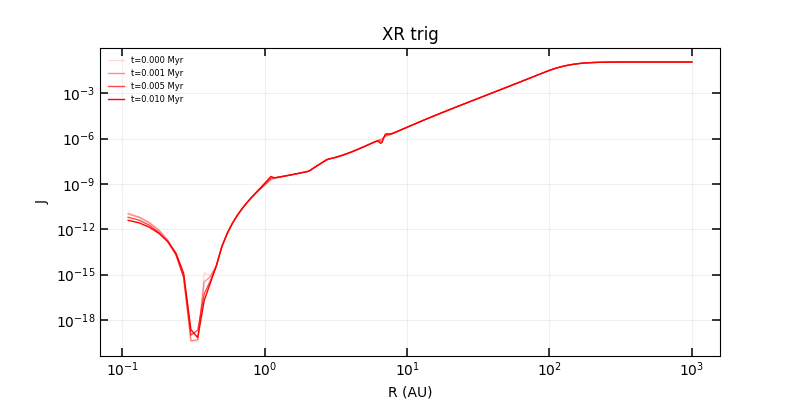

In [29]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)


#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))

xdata = trR
ydata = trJ

for a_i, i in enumerate(idx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={crt[i]/1e6:.3f} Myr", lw = 1.0)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('J')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('XR trig')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

Text(0.5, 1.0, 'XR trig')

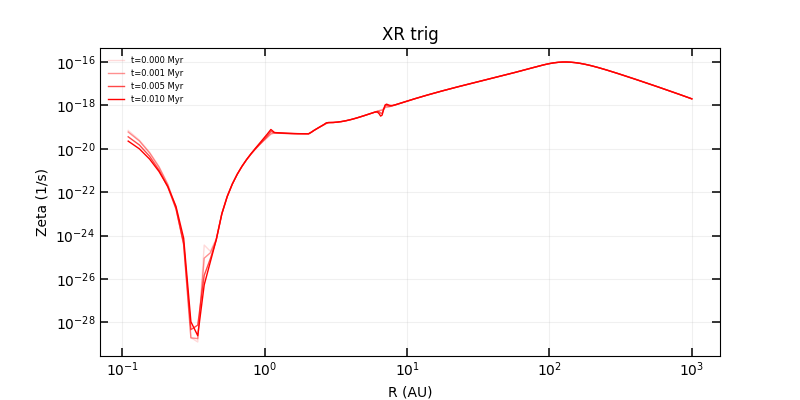

In [30]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)


#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))

xdata = trR
ydata = trZeta

for a_i, i in enumerate(idx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={crt[i]/1e6:.3f} Myr", lw = 1.0)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('XR trig')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

# Sept 1

alpha prime = arctan(source_z / R - source_R)

In [31]:
Path = "/Users/james/Documents/GitHub/DiscEvolution/james/august2026/output/XR_0.01Myr/trig/winds_mig_psi10.0_Mdot1.0e-08_M1.0e-01_Rd5.0e+01_20260901_145414.h5"
with h5py.File(Path, "r") as f:
    data = h5_to_dict(f)
    attrs = dict(f.attrs)

In [32]:
R = data["R"]
tsnap = data["time_snap"]    # Myr        
Sigma_g = data["Sigma_G"]   

Rdz = data['R_dz_t']
t = data["t"]                # yr

Zeta = data['zeta']
ZetaCR = data['zeta_CR']
ZetaXR = data['zeta_XR']

Lambda = data['Lambda']
T = data['T']
NH = data['NH']
J = data['JXR']
sigma = data['sigmaXR']
tau = data['tau_XR']

H = data['H']
xe = data['xe']

In [33]:
arr1 = tsnap*1e6
arr2 = t

# Find the insertion positions
idx = np.searchsorted(arr2, arr1)

# Handle edge cases where the index falls outside array boundaries
idx = np.clip(idx, 1, len(arr2) - 1)

# Check whether the left or right neighbor is closer
left_closer = np.abs(arr1 - arr2[idx - 1]) < np.abs(arr1 - arr2[idx])
closest_indices = np.where(left_closer, idx - 1, idx)

print(closest_indices)

[  0  35 181 342]


Text(0.5, 1.0, 'Sept 1')

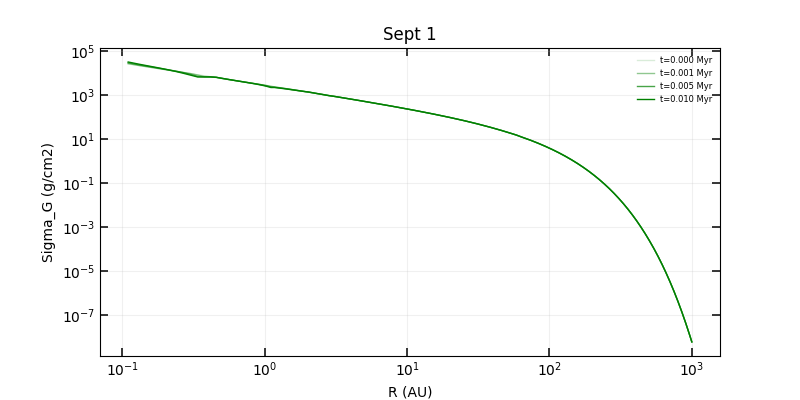

In [34]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)

#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(crtsnap))

xdata = R
ydata = Sigma_g

for a_i, i in enumerate(range(0,4)):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"t={crtsnap[i]:.3f} Myr", lw = 1.0)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('Sigma_G (g/cm2)')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('Sept 1')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

Text(0.5, 1.0, 'Sept 1')

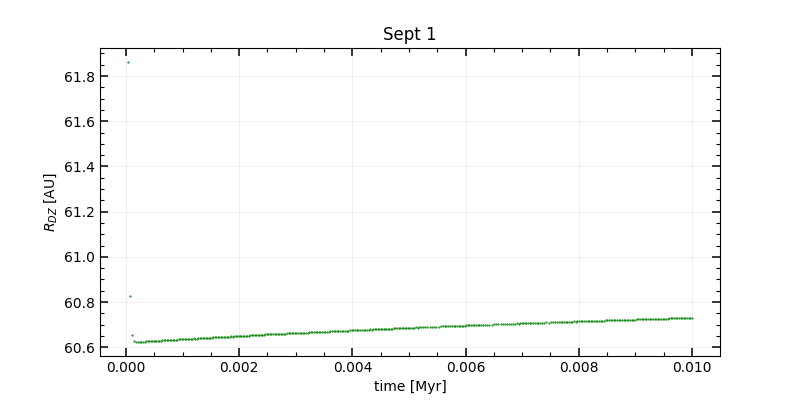

In [35]:
fig, ax = plt.subplots(figsize=(8, 4), sharex=True, dpi=100, sharey=True)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

plt.plot(t/1e6, Rdz, '.g', ms = 1.0)
ax.set_ylabel(r'$R_{DZ}$ [AU]')
ax.set_xlabel('time [Myr]')
plt.title('Sept 1')

# ax.legend(frameon=False, fontsize=9, loc="best")

Text(0.5, 1.0, 'Sept 1')

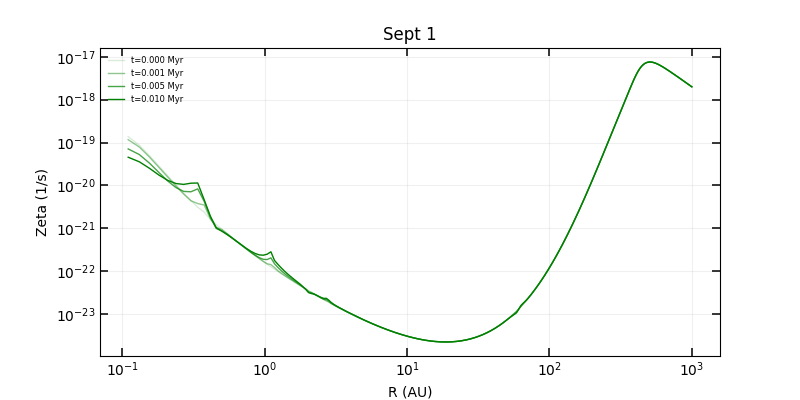

In [36]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)


#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))

xdata = R
ydata = Zeta

for a_i, i in enumerate(idx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"t={crt[i]/1e6:.3f} Myr", lw = 1.0)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('Sept 1')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

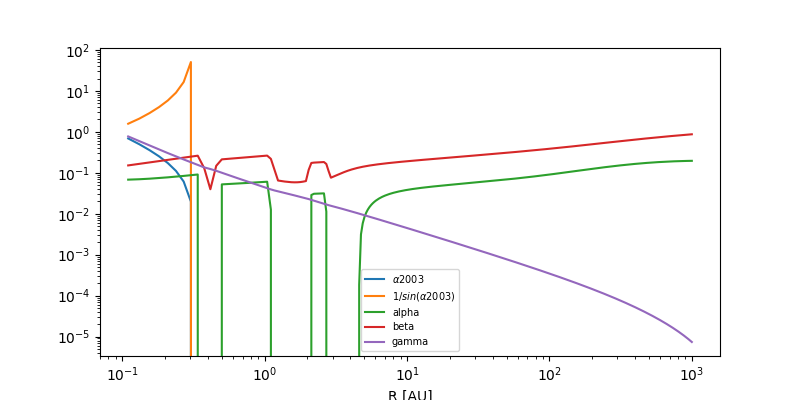

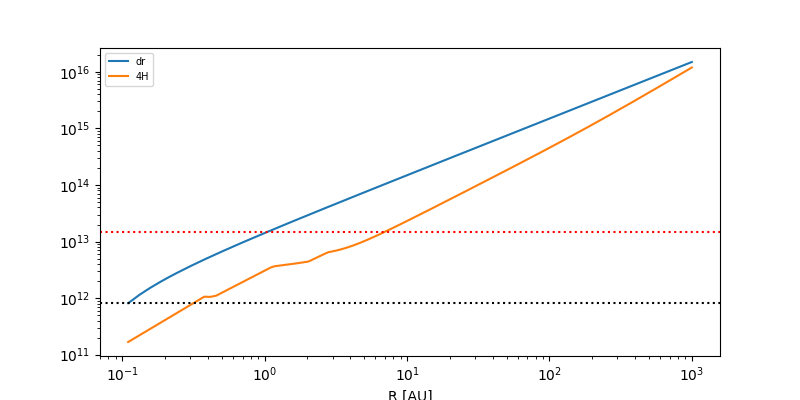

In [37]:
source_R = 12.0 * Rsun
source_z = 12.0 * Rsun
R_cm = R * AU             # Not a fx of t , R only saved once (1000,)
fourH = 4 * H * AU

dr = R_cm - source_R
dz = source_z
alpha_prime = np.arctan2(dz, dr) # y, x
geometry_factor = 1.0 / np.sin(alpha_prime)

Nperp = Sigma_g / (2.0 * 2.4 * m_H)



Rstar = 1.0 * Rsun                       # cm
H4 = 4.0 * H[0] * AU                             # cm

# disk radius
a = R * AU                                   # cm

dlnH_dlna = np.gradient(np.log(H4), np.log(a))      # unitless

# Chiang 2001
alpha = np.arctan( dlnH_dlna * (H4 / a) ) - np.arctan( H4 / a ) + np.arcsin( (4 * Rstar)/( 3*np.pi*a) ) 

# Matsumura & Pudritz 2003
beta = np.arctan( dlnH_dlna * (H4 / a) )

# Matsumura & Pudritz 2003
gamma = np.arctan( (H4 - 0.5*Rstar)/(a - 0.5*np.sqrt(3)*Rstar) ) - np.arctan( (H4 - source_z)/(a - source_R) )

alpha_2003 = alpha - beta + gamma
sin2003 = np.sin(alpha_2003)



fig, ax = plt.subplots(figsize=(8, 4))
# ax.loglog(R, Nperp[0], label=r"$N_\perp$")
# ax.loglog(R, geometry_factor, label=r"$1/sin(\alpha')$")
# ax.loglog(R, NH[0], label=r"$N_H$")
# ax.loglog(R, Nperp[0] * geometry_factor, label=r"$N_\perp * 1/sin(\alpha')$")
# ax.loglog(R, alpha_prime, label=r"$\alpha'$")
ax.loglog(R, alpha_2003, label=r"$\alpha 2003$")
ax.loglog(R,1.0 / sin2003, label=r"$1/sin(\alpha2003)$")
ax.loglog(R,alpha, label = 'alpha')
ax.loglog(R,beta, label = 'beta')
ax.loglog(R,gamma, label = 'gamma')
ax.set_xlabel("R [AU]")
ax.set_ylabel("")
ax.legend(loc='best',fontsize=7)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(R, dr, label=r"dr")
# ax.loglog(R, dz, label=r"dz")
ax.loglog(R, fourH[0], label=r"4H")
ax.axhline(y = source_z, ls = 'dotted', color = 'black')
ax.axhline(y = AU, ls = 'dotted', color = 'red')
ax.set_xlabel("R [AU]")
ax.set_ylabel("")
ax.legend(loc='best',fontsize=7)
plt.show()

Text(0.5, 1.0, 'Sept 1')

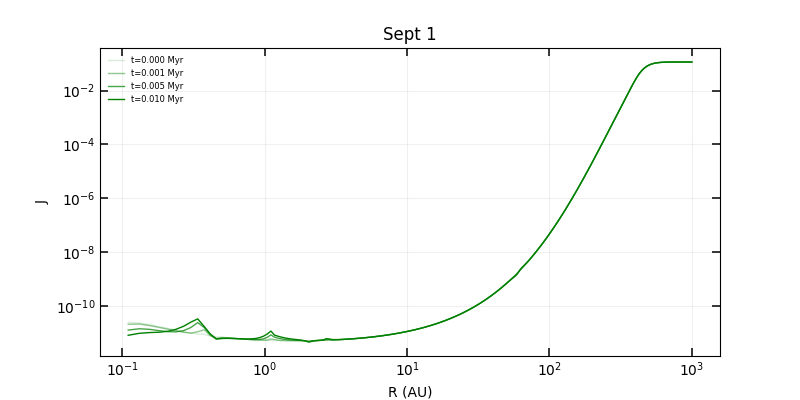

In [38]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)


#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))

xdata = R
ydata = J

for a_i, i in enumerate(idx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"t={crt[i]/1e6:.3f} Myr", lw = 1.0)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('J')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('Sept 1')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

Text(0.5, 1.0, 'Sept 1')

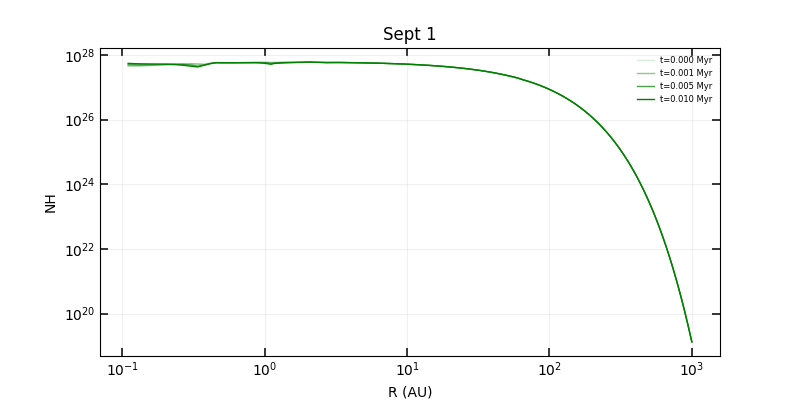

In [39]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)


#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))

xdata = R
ydata = NH

for a_i, i in enumerate(idx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"t={crt[i]/1e6:.3f} Myr", lw = 1.0)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('NH')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('Sept 1')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

Text(0.5, 1.0, 'Sept 1')

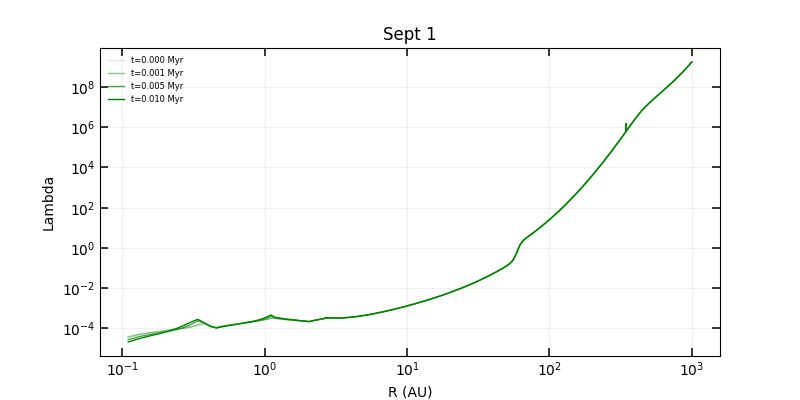

In [40]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)


#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))

xdata = R
ydata = Lambda

for a_i, i in enumerate(idx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"t={crt[i]/1e6:.3f} Myr", lw = 1.0)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('Lambda')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('Sept 1')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

Text(0.5, 1.0, 'Sept 1')

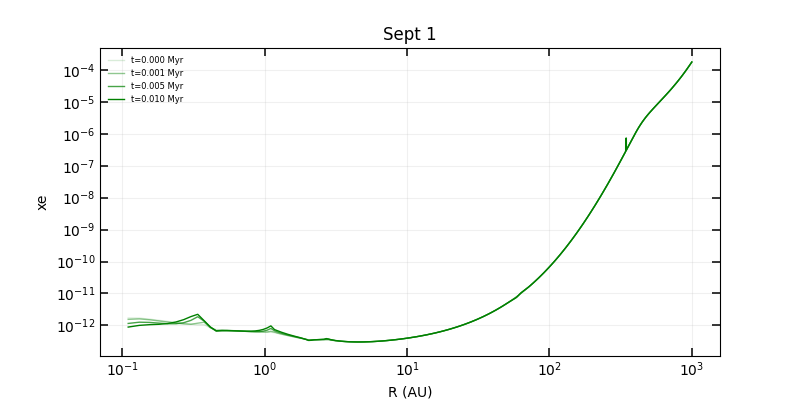

In [41]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)


#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))

xdata = R
ydata = xe

for a_i, i in enumerate(idx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"t={crt[i]/1e6:.3f} Myr", lw = 1.0)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('xe')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('Sept 1')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

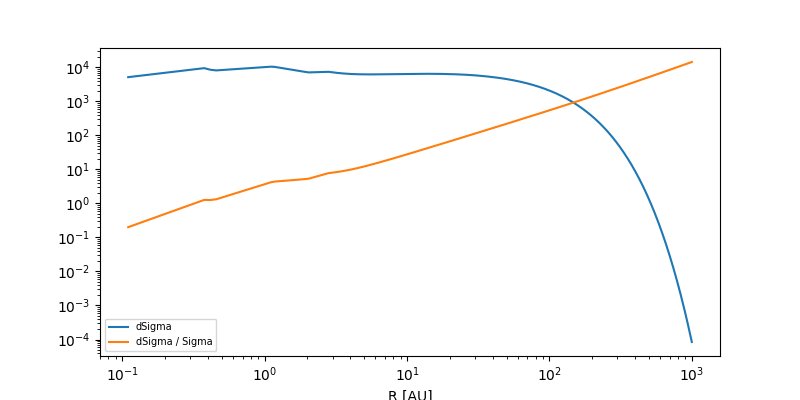

In [42]:
source_R = 12.0 * Rsun
source_z = 12.0 * Rsun
R_cm = R * AU             # Not a fx of t , R only saved once (1000,)
fourH = 4 * H * AU

dr = R_cm - source_R
dz = source_z
deltaR = (fourH * dr)/(dz)
R4H = R_cm - deltaR[0]


Nperp_R = Sigma_g / (2.0 * 2.4 * m_H)

deltaSig = (Sigma_g * (H * AU) ) / (3 * Rsun)

fig, ax = plt.subplots(figsize=(8, 4))

# ax.loglog(R, Nperp_R[0], label=r"$N_\perp$")
ax.loglog(R, deltaSig[0], label=r"dSigma")
ax.loglog(R, deltaSig[0] / Sigma_g[0], label=r"dSigma / Sigma")
# ax.semilogx(R, deltaR[0] / AU)

ax.set_xlabel("R [AU]")
ax.set_ylabel("")
ax.legend(loc='best',fontsize=7)
plt.show()

# CR XR 

In [43]:
CXPath = "/Users/james/Documents/GitHub/DiscEvolution/james/august2026/output/CRXR_0.1Myr/trig/winds_mig_psi10.0_Mdot1.0e-08_M1.0e-01_Rd5.0e+01_20260901_153342.h5"
with h5py.File(CXPath, "r") as f:
    CXdata = h5_to_dict(f)
    CXattrs = dict(f.attrs)

In [44]:
cxR = CXdata["R"]
cxtsnap = CXdata["time_snap"]    # Myr  
cxSigma_g = CXdata["Sigma_G"]   

cxRdz = CXdata['R_dz_t']
cxt = CXdata["t"]                # yr

cxZeta = CXdata['zeta']
cxZetaCR = CXdata['zeta_CR']
cxZetaXR = CXdata['zeta_XR']

cxLambda = CXdata['Lambda']
cxT = CXdata['T']
cxNH = CXdata['NH']
cxJ = CXdata['JXR']
cxsigma = CXdata['sigmaXR']
cxtau = CXdata['tau_XR']

cxH = CXdata['H']
cxxe = CXdata['xe']

Text(0.5, 1.0, 'Sept 1')

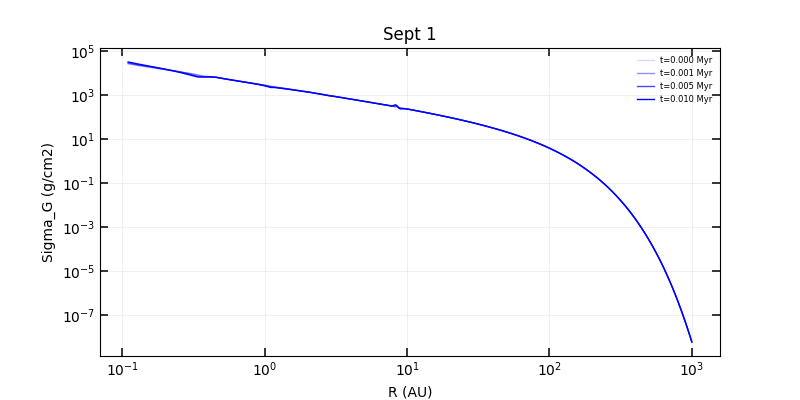

In [45]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)

#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(crtsnap))

xdata = cxR
ydata = cxSigma_g

for a_i, i in enumerate(range(0,4)):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='blue', alpha=alphas[a_i],
                label=rf"t={crtsnap[i]:.3f} Myr", lw = 1.0)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('Sigma_G (g/cm2)')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('Sept 1')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

Text(0.5, 1.0, 'Sept 1')

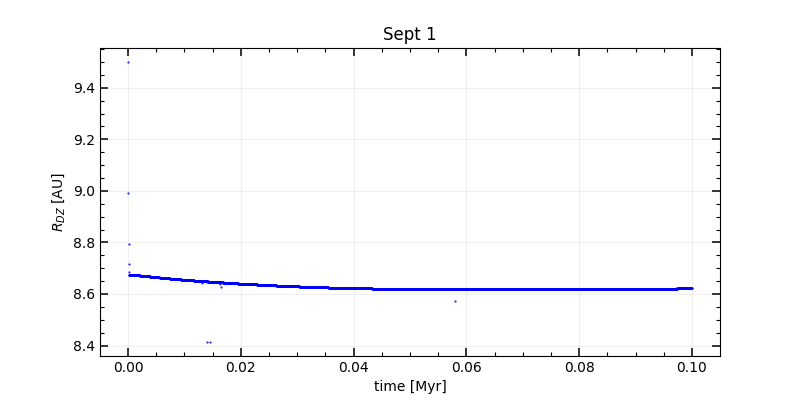

In [46]:
fig, ax = plt.subplots(figsize=(8, 4), sharex=True, dpi=100, sharey=True)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

plt.plot(cxt/1e6, cxRdz, '.b', ms = 1.0)
ax.set_ylabel(r'$R_{DZ}$ [AU]')
ax.set_xlabel('time [Myr]')
plt.title('Sept 1')

# ax.legend(frameon=False, fontsize=9, loc="best")

Text(0.5, 1.0, 'Sept 1')

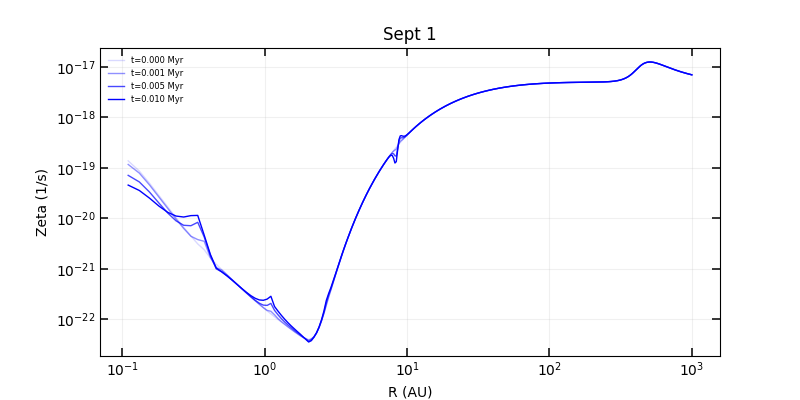

In [47]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)


#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))

xdata = cxR
ydata = cxZeta

for a_i, i in enumerate(idx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='blue', alpha=alphas[a_i],
                label=rf"t={crt[i]/1e6:.3f} Myr", lw = 1.0)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('Sept 1')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

(1e-50, 1e-05)

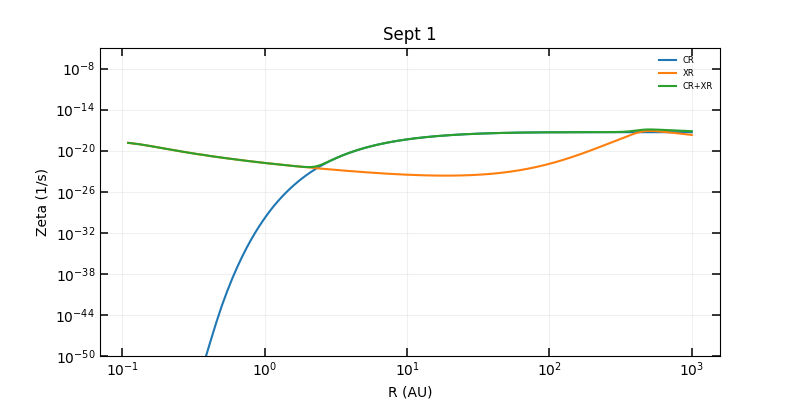

In [48]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)


#color gradient (one alpha per shown snapshot; single snapshot = full opacity)

ax.loglog(cxR, cxZetaCR[0], label = 'CR')
ax.loglog(cxR, cxZetaXR[0], label = 'XR')

ax.loglog(cxR, cxZeta[0], label = 'CR+XR')



# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('Sept 1')

#ax.set_xlim(8,10)
ax.set_ylim(1e-50,1e-5)

Text(0.5, 1.0, 'Sept 1')

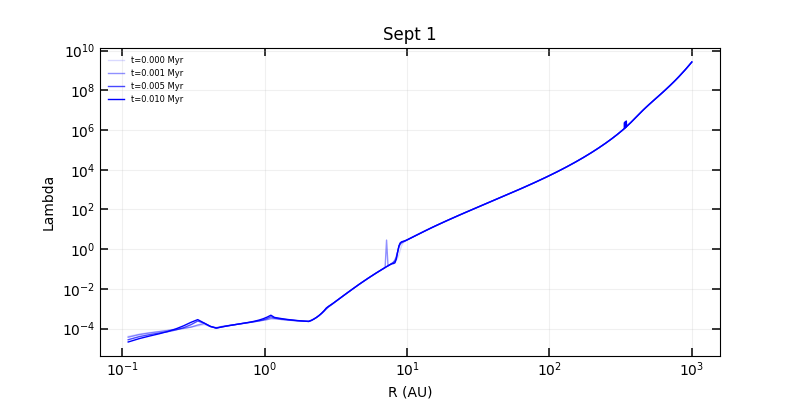

In [49]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)


#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))

xdata = cxR
ydata = cxLambda

for a_i, i in enumerate(idx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='blue', alpha=alphas[a_i],
                label=rf"t={crt[i]/1e6:.3f} Myr", lw = 1.0)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('Lambda')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('Sept 1')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

Text(0.5, 1.0, 'Sept 1')

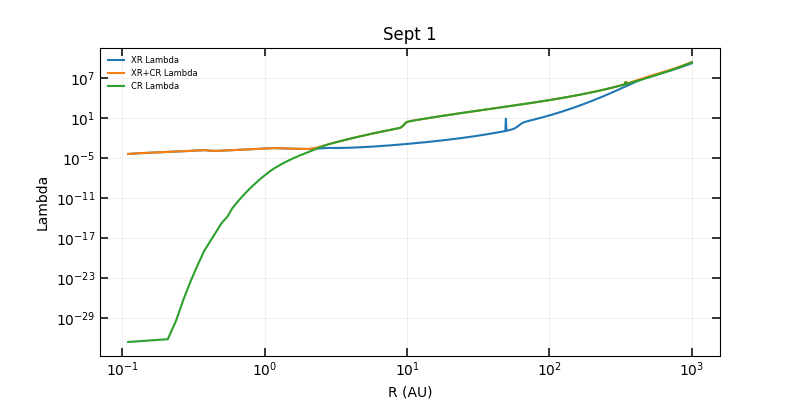

In [50]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)

ax.loglog(R,Lambda[0], label='XR Lambda')
ax.loglog(R,cxLambda[0], label='XR+CR Lambda')
ax.loglog(R,crLambda[0], label='CR Lambda')

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('Lambda')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('Sept 1')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

Text(0.5, 1.0, 'Sept 1')

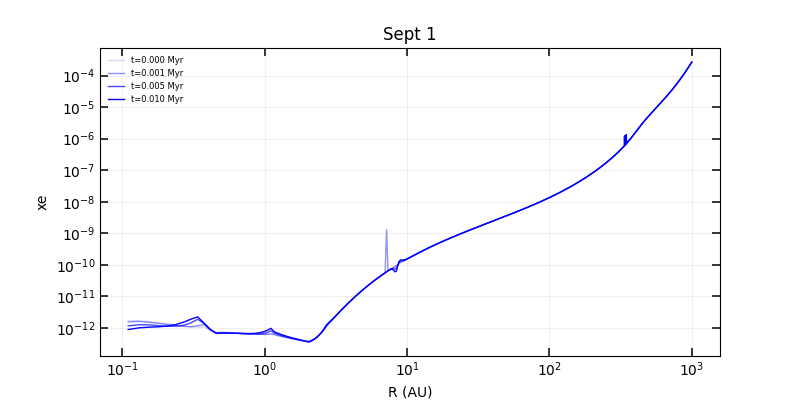

In [51]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)


#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))

xdata = cxR
ydata = cxxe

for a_i, i in enumerate(idx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='blue', alpha=alphas[a_i],
                label=rf"t={crt[i]/1e6:.3f} Myr", lw = 1.0)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('xe')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('Sept 1')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

Text(0.5, 1.0, 'CR')

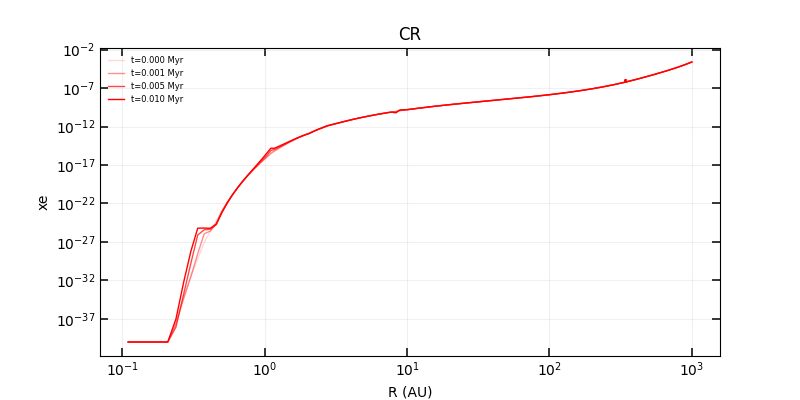

In [52]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)


#color gradient (one alpha per shown snapshot; single snapshot = full opacity)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))

xdata = crR
ydata = crxe

for a_i, i in enumerate(idx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={crt[i]/1e6:.3f} Myr", lw = 1.0)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('xe')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('CR')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

Text(0.5, 1.0, 'Sept 1')

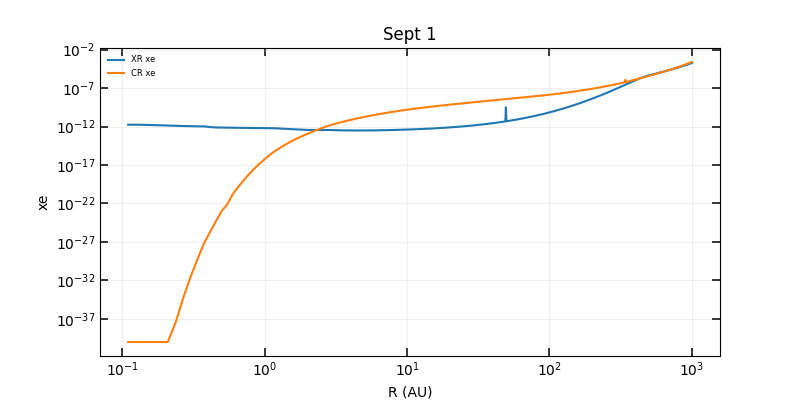

In [53]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)

ax.loglog(R,xe[0], label='XR xe')
ax.loglog(R,crxe[0], label='CR xe ')
# ax.loglog(R,cxxe[0], label='XR+CR xe')

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('xe')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('Sept 1')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

Text(0.5, 1.0, 'Sept 1')

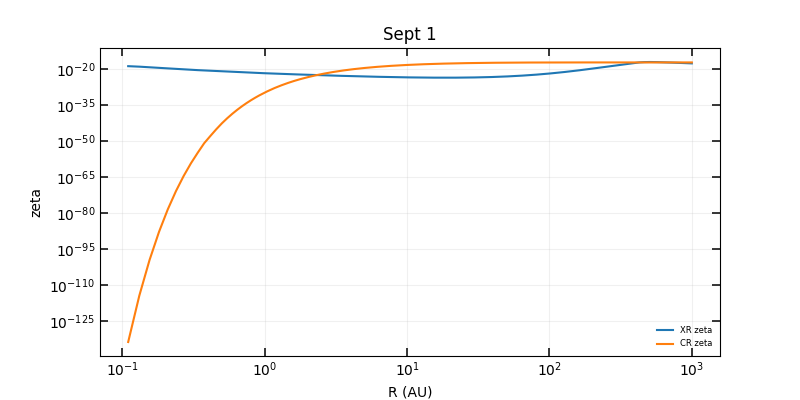

In [54]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)

ax.loglog(R,Zeta[0], label='XR zeta')
# ax.loglog(R,cxLambda[0], label='XR+CR Lambda')
ax.loglog(R,crZeta[0], label='CR zeta')

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('zeta')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('Sept 1')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

Text(0.5, 1.0, 'Sept 1')

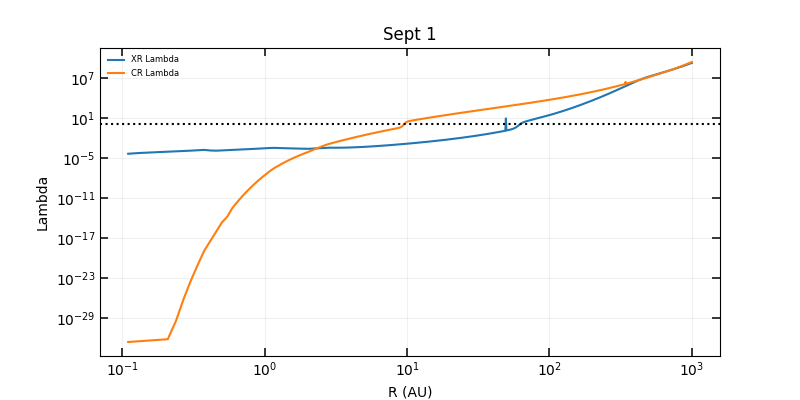

In [55]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)

ax.loglog(R,Lambda[0], label='XR Lambda')
ax.loglog(R,crLambda[0], label='CR Lambda ')
ax.axhline(1, ls = 'dotted', color = 'black')
# ax.loglog(R,cxxe[0], label='XR+CR xe')

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('R (AU)')
ax.set_ylabel('Lambda')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('Sept 1')

#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

# Sept 2

Text(0.5, 1.0, 'Nperp at 4H and R')

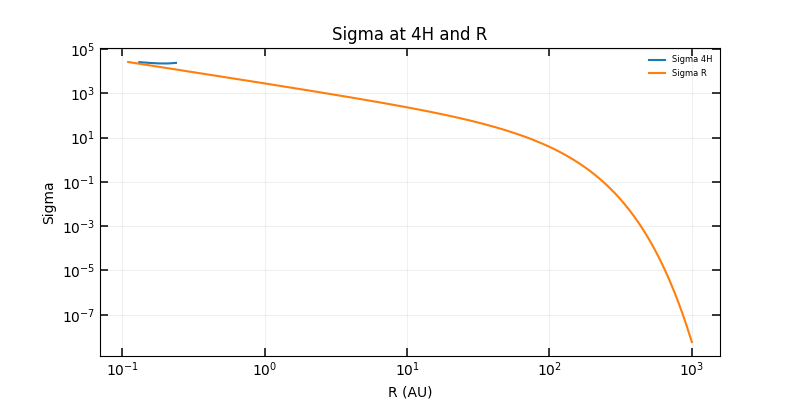

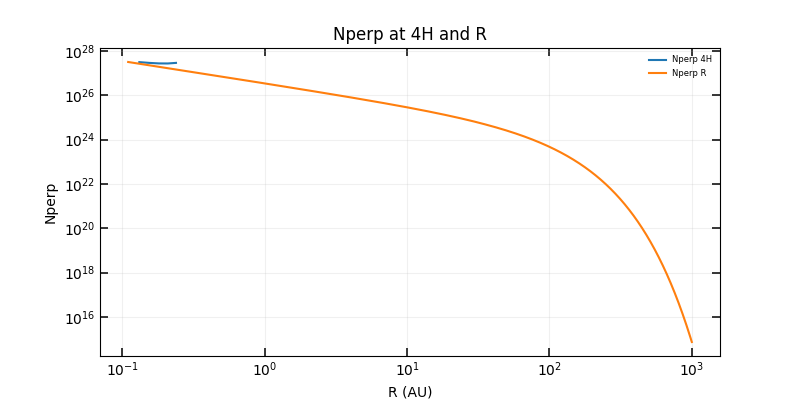

In [71]:
source_R = 12.0 * Rsun
source_z = 12.0 * Rsun
R_cm = R * AU               # Not a fx of t , R only saved once (1000,)
fourH = 4 * H * AU          # cm

dr = R_cm - source_R        # cm    
dz = source_z               # cm 
deltaR = (fourH * dr)/(dz)  # cm 
R4H = R_cm - deltaR[0]      # cm            # at t = 0

R4H_AU = R4H / AU           # AU

Sigma_4H = np.interp(
    R4H_AU,
    R,
    Sigma_g[0],
    left=np.nan,
    right=np.nan,
)

Nperp_R = Sigma_g / (2.0 * 2.4 * m_H)
Nperp_4H = Sigma_4H / (2.0 * 2.4 * m_H)



fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)
ax.loglog(R,Sigma_4H, label='Sigma 4H')
ax.loglog(R,Sigma_g[0], label='Sigma R')

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Sigma')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('Sigma at 4H and R')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)


fig, ax = plt.subplots(figsize=(8, 4), dpi = 100)
ax.loglog(R,Nperp_4H, label='Nperp 4H')
ax.loglog(R,Nperp_R[0], label='Nperp R')

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Nperp')
ax.legend(frameon=False, fontsize=6, loc="best")
plt.title('Nperp at 4H and R')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

In [72]:
R4H_AU

array([ 9.92575412e-02,  1.11920698e-01,  1.22029493e-01,  1.28188969e-01,
        1.28754815e-01,  1.21813578e-01,  1.05162880e-01,  7.62916198e-02,
        3.23601950e-02, -2.98192928e-02, -3.71040134e-02, -7.36278330e-02,
       -1.61086196e-01, -2.70078536e-01, -4.03463688e-01, -5.64301765e-01,
       -7.55859045e-01, -9.81612760e-01, -1.24525579e+00, -1.55070126e+00,
       -1.90208706e+00, -2.30378031e+00, -2.76038166e+00, -3.27672957e+00,
       -3.71723872e+00, -4.04583904e+00, -4.39200234e+00, -4.75646196e+00,
       -5.14013025e+00, -5.54416306e+00, -5.97003470e+00, -6.41961911e+00,
       -6.89528231e+00, -7.39995643e+00, -7.93720113e+00, -8.51121145e+00,
       -9.48108440e+00, -1.05435337e+01, -1.16904758e+01, -1.29263536e+01,
       -1.42557375e+01, -1.56833268e+01, -1.72139500e+01, -1.86343936e+01,
       -1.97555767e+01, -2.09505915e+01, -2.22268047e+01, -2.35916440e+01,
       -2.50524514e+01, -2.66163623e+01, -2.82902414e+01, -3.00806641e+01,
       -3.19939358e+01, -